# Notebook 06: 驻留时间、Hartman 效应与超光速隧穿

---

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
from config import SimParams
from potentials import get_potential
from propagator import propagate
from observables import (
    eckart_analytical_T_simple, square_analytical_phase_time
)

plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 13, 'axes.titlesize': 14,
    'legend.fontsize': 10, 'lines.linewidth': 1.5,
    'axes.grid': True, 'grid.alpha': 0.3,
})

## 1. 隧穿时间问题

量子隧穿时间是量子力学中尚未完全解决的问题。主要定义：

**驻留时间 (Dwell Time)**：粒子在势垒区域 $[a,b]$ 内停留的平均时间
$$\tau_D = \int_0^\infty dt \int_a^b |\psi(x,t)|^2\,dx$$

**相位时间 (Phase Time)**：透射波包的群延迟
$$\tau_\phi = \frac{\partial \phi_T}{\partial E}$$
其中 $\phi_T$ 为透射振幅 $t(E) = \sqrt{T}\,e^{i\phi_T}$ 的相位。

**自由传播时间**：无势垒时穿越同样距离所需时间
$$\tau_0 = \frac{L}{v_g} = \frac{L}{k_0}$$

**Hartman 效应**：当势垒足够厚 ($\kappa L \gg 1$) 时，隧穿时间 $\tau_D$ 和 $\tau_\phi$ 趋于饱和，不再随势垒宽度 $L$ 增大，导致有效隧穿速度 $v_{\text{eff}} = L/\tau$ 可以超过自由粒子速度 $v_g$。

## 2. 方势垒：驻留时间 vs 势垒宽度

固定 $V_0=15$, $k_0=5$ ($E=12.5 < V_0$)，改变势垒宽度 $L$

In [2]:
widths = np.array([0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0])
dwell_times = []
phase_times_ana = []
free_times = []

V0, k0 = 15.0, 5.0
E = 0.5 * k0**2

for w in widths:
    p_w = SimParams(V0=V0, k0=k0, sigma=10.0, x0=-30.0, N_x=4096,
                     N_t=4000, save_every=200, dt=0.005,
                     barrier_a=-w/2, barrier_b=w/2)
    res = propagate(p_w, 'square')
    dwell_times.append(res.dwell_time)
    phase_times_ana.append(square_analytical_phase_time(E, V0, w))
    free_times.append(w / k0)
    print(f'L={w:5.1f}: τ_D={res.dwell_time:.4f}, τ_φ(ana)={phase_times_ana[-1]:.4f}, τ_0={free_times[-1]:.4f}, v_eff/v_g={w/(phase_times_ana[-1]*k0):.2f}')

dwell_times = np.array(dwell_times)
phase_times_ana = np.array(phase_times_ana)
free_times = np.array(free_times)

L=  0.5: τ_D=0.0675, τ_φ(ana)=0.0029, τ_0=0.1000, v_eff/v_g=33.96
L=  1.0: τ_D=0.1174, τ_φ(ana)=0.0200, τ_0=0.2000, v_eff/v_g=10.00
L=  1.5: τ_D=0.1252, τ_φ(ana)=0.0351, τ_0=0.3000, v_eff/v_g=8.54
L=  2.0: τ_D=0.1272, τ_φ(ana)=0.0501, τ_0=0.4000, v_eff/v_g=7.99
L=  3.0: τ_D=0.1279, τ_φ(ana)=0.0799, τ_0=0.6000, v_eff/v_g=7.51
L=  4.0: τ_D=0.1287, τ_φ(ana)=0.1097, τ_0=0.8000, v_eff/v_g=7.29
L=  6.0: τ_D=0.1309, τ_φ(ana)=0.1693, τ_0=1.2000, v_eff/v_g=7.09
L=  8.0: τ_D=0.1344, τ_φ(ana)=0.2290, τ_0=1.6000, v_eff/v_g=6.99
L= 10.0: τ_D=0.1395, τ_φ(ana)=0.2886, τ_0=2.0000, v_eff/v_g=6.93
L= 12.0: τ_D=0.1475, τ_φ(ana)=0.3482, τ_0=2.4000, v_eff/v_g=6.89
L= 16.0: τ_D=0.1739, τ_φ(ana)=0.4675, τ_0=3.2000, v_eff/v_g=6.85
L= 20.0: τ_D=0.2249, τ_φ(ana)=0.5867, τ_0=4.0000, v_eff/v_g=6.82


### Hartman 效应验证图

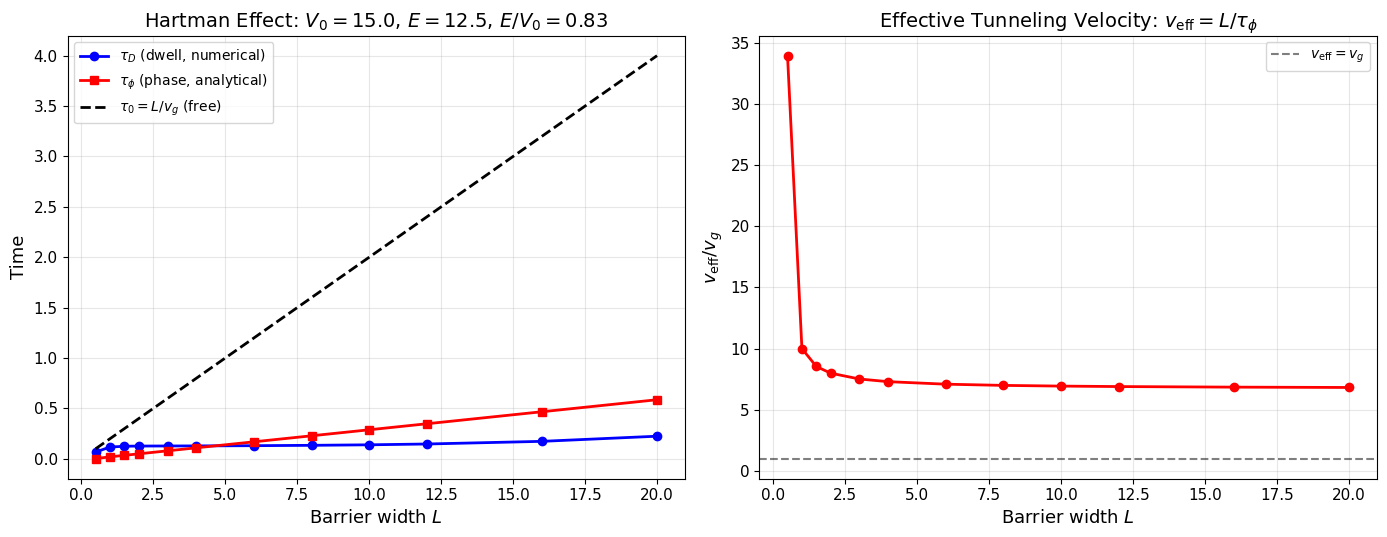

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

ax1.plot(widths, dwell_times, 'bo-', linewidth=2, markersize=6, label=r'$\tau_D$ (dwell, numerical)')
ax1.plot(widths, phase_times_ana, 'rs-', linewidth=2, markersize=6, label=r'$\tau_\phi$ (phase, analytical)')
ax1.plot(widths, free_times, 'k--', linewidth=2, label=r'$\tau_0 = L/v_g$ (free)')
ax1.set_xlabel('Barrier width $L$')
ax1.set_ylabel('Time')
ax1.set_title(f'Hartman Effect: $V_0={V0}$, $E={E}$, $E/V_0={E/V0:.2f}$')
ax1.legend()

v_eff = widths / phase_times_ana
v_g = k0
ax2.plot(widths, v_eff / v_g, 'ro-', linewidth=2, markersize=6)
ax2.axhline(1.0, color='k', linestyle='--', alpha=0.5, label=r'$v_{\mathrm{eff}} = v_g$')
ax2.set_xlabel('Barrier width $L$')
ax2.set_ylabel(r'$v_{\mathrm{eff}} / v_g$')
ax2.set_title(r'Effective Tunneling Velocity: $v_{\mathrm{eff}} = L / \tau_\phi$')
ax2.legend()

plt.tight_layout()
plt.show()

## 3. 势垒区概率的时间演化

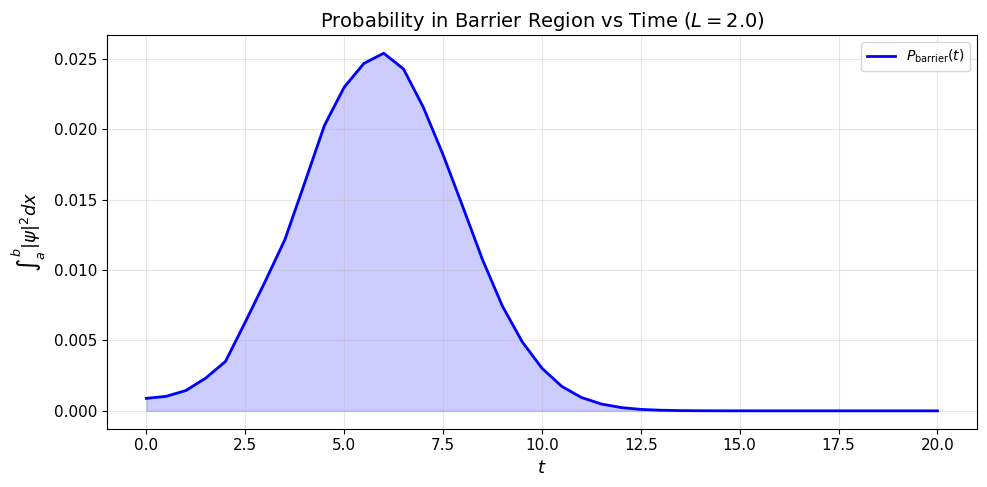

Dwell time = 0.127234


In [4]:
p_ref = SimParams(V0=V0, k0=k0, sigma=10.0, x0=-30.0, N_x=4096,
                   N_t=4000, save_every=100, dt=0.005)
res_ref = propagate(p_ref, 'square')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_ref.times, res_ref.barrier_prob_t, 'b-', linewidth=2, label=r'$P_{\mathrm{barrier}}(t)$')
ax.fill_between(res_ref.times, 0, res_ref.barrier_prob_t, alpha=0.2, color='blue')
ax.set_xlabel('$t$')
ax.set_ylabel(r'$\int_a^b |\psi|^2 dx$')
ax.set_title(f'Probability in Barrier Region vs Time ($L={p_ref.barrier_b-p_ref.barrier_a}$)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Dwell time = {res_ref.dwell_time:.6f}')

## 4. 不同能量下的 Hartman 效应

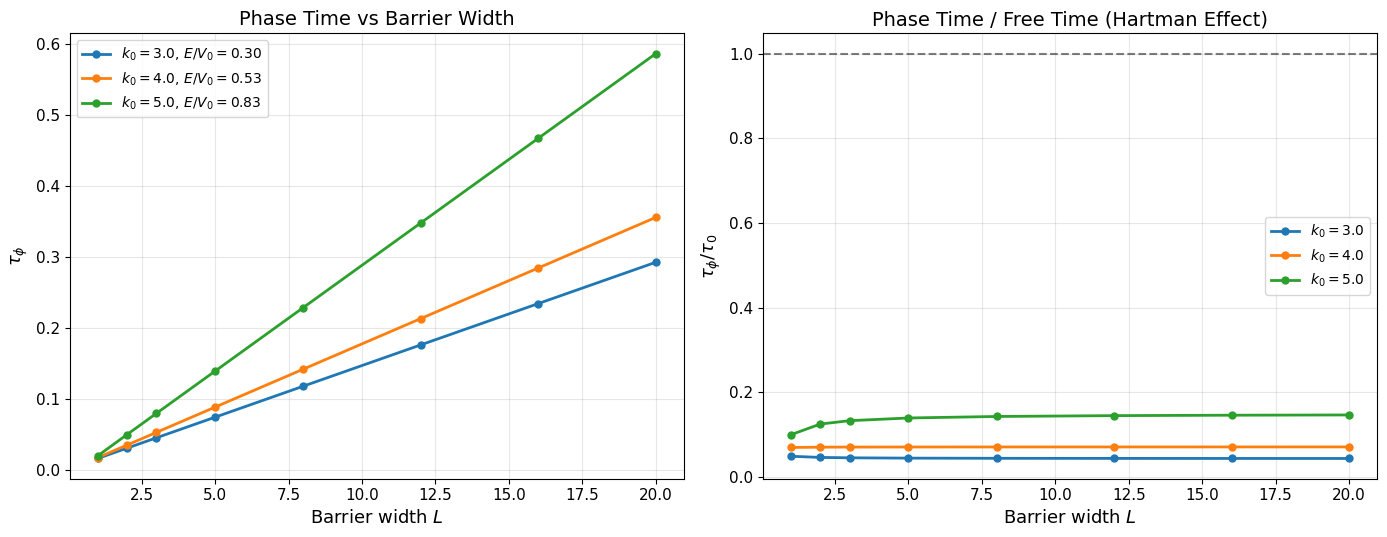

In [5]:
k0_values = [3.0, 4.0, 5.0]
widths_scan = np.array([1.0, 2.0, 3.0, 5.0, 8.0, 12.0, 16.0, 20.0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for k0 in k0_values:
    E = 0.5 * k0**2
    tau_phi_list = []
    tau0_list = []
    for w in widths_scan:
        tau_phi_list.append(square_analytical_phase_time(E, V0, w))
        tau0_list.append(w / k0)
    tau_phi = np.array(tau_phi_list)
    tau0 = np.array(tau0_list)
    ax1.plot(widths_scan, tau_phi, 'o-', linewidth=2, markersize=5,
             label=f'$k_0={k0}$, $E/V_0={E/V0:.2f}$')
    ax2.plot(widths_scan, tau_phi / tau0, 'o-', linewidth=2, markersize=5,
             label=f'$k_0={k0}$')

ax1.set_xlabel('Barrier width $L$')
ax1.set_ylabel(r'$\tau_\phi$')
ax1.set_title(r'Phase Time vs Barrier Width')
ax1.legend()

ax2.axhline(1.0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Barrier width $L$')
ax2.set_ylabel(r'$\tau_\phi / \tau_0$')
ax2.set_title(r'Phase Time / Free Time (Hartman Effect)')
ax2.legend()

plt.tight_layout()
plt.show()

## 5. 超光速隧穿讨论

当 $\tau_\phi < \tau_0$ 时，有效隧穿速度 $v_{\mathrm{eff}} = L/\tau_\phi > v_g$。

在非相对论量子力学中 ($c \to \infty$)，$v_g$ 本身没有上限，故"超光速"需要在相对论框架下讨论。
但 Hartman 效应的核心物理是：**隧穿时间不依赖于势垒厚度**，这与经典粒子穿越势垒所需时间必然随距离增大的直觉相悖。

在物理实验中（如 Steinberg et al. 1993 的光子隧穿实验），观测到隧穿光子的群延迟确实短于真空传播时间，
但这不违反因果律和相对论，原因如下：

1. **前沿速度 (front velocity) ≤ c**：波包的前沿（最早到达的极小振幅部分）传播速度不超过 c
2. **信息速度 ≠ 群速度**：群速度可以超过 c，但信息传递受前沿速度限制
3. **波包重塑**：透射波包并非入射波包的完整时间平移，而是势垒对高频分量进行滤波后的"重塑"——
   透射峰的提前到达是概率分布再分配的结果，而非超光速信号传播
4. **Hartman 效应的本质**：厚势垒几乎完全反射低概率尾部，仅允许波包最前端的高频成分通过，
   这些成分本就传播较快，因此有效群延迟缩短

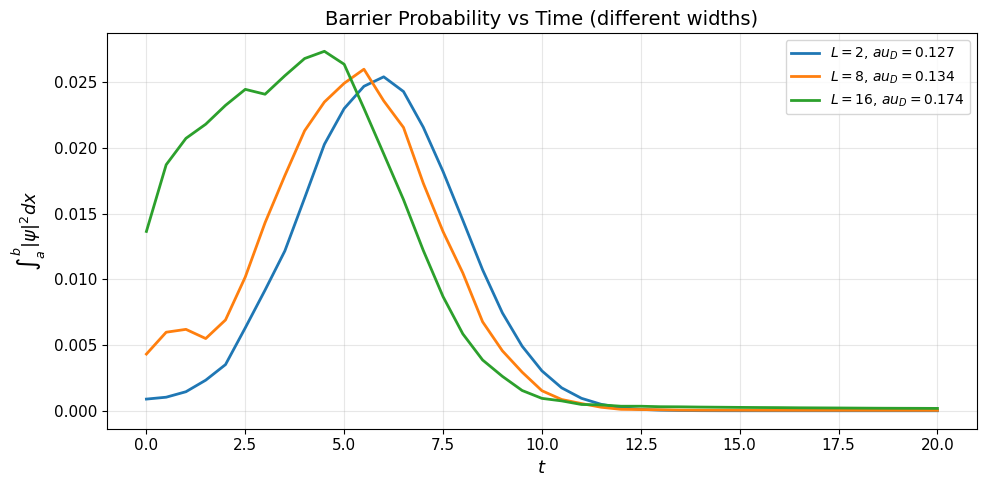

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

for w in [2.0, 8.0, 16.0]:
    p_w = SimParams(V0=V0, k0=k0, sigma=10.0, x0=-30.0, N_x=4096,
                     N_t=4000, save_every=100, dt=0.005,
                     barrier_a=-w/2, barrier_b=w/2)
    res_w = propagate(p_w, 'square')
    ax.plot(res_w.times, res_w.barrier_prob_t, linewidth=2,
            label=f'$L={w:.0f}$, $\tau_D={res_w.dwell_time:.3f}$')

ax.set_xlabel('$t$')
ax.set_ylabel(r'$\int_a^b |\psi|^2 dx$')
ax.set_title('Barrier Probability vs Time (different widths)')
ax.legend()
plt.tight_layout()
plt.show()

## 6. 透射波包的时间提前 — 波包重塑

比较透射波包与自由传播波包的到达时间，观察透射峰是否提前到达

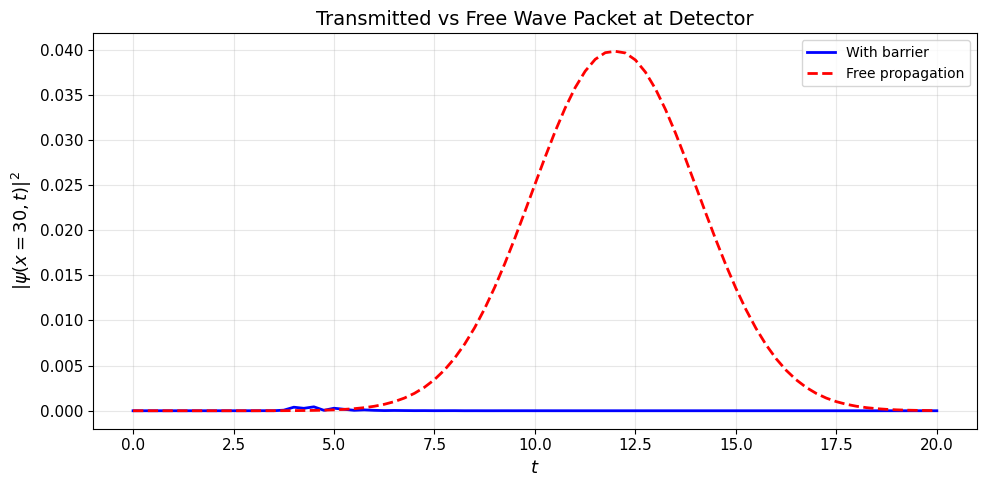

In [7]:
p_tunnel = SimParams(V0=V0, k0=k0, sigma=10.0, x0=-30.0, N_x=4096,
                      N_t=4000, save_every=50, dt=0.005, barrier_a=-2.0, barrier_b=2.0)
res_tunnel = propagate(p_tunnel, 'square')

p_free = SimParams(V0=0.0, k0=k0, sigma=10.0, x0=-30.0, N_x=4096,
                     N_t=4000, save_every=50, dt=0.005, barrier_a=-2.0, barrier_b=2.0)
res_free = propagate(p_free, 'square')

x = p_tunnel.x
x_detect = 30.0

prob_tunnel_detect = []
prob_free_detect = []
for i in range(len(res_tunnel.times)):
    rho_t = res_tunnel.prob_densities[i]
    rho_f = res_free.prob_densities[i]
    idx = np.argmin(np.abs(x - x_detect))
    prob_tunnel_detect.append(rho_t[max(idx-5,0):idx+5].max())
    prob_free_detect.append(rho_f[max(idx-5,0):idx+5].max())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(res_tunnel.times, prob_tunnel_detect, 'b-', linewidth=2, label='With barrier')
ax.plot(res_free.times, prob_free_detect, 'r--', linewidth=2, label='Free propagation')
ax.set_xlabel('$t$')
ax.set_ylabel(f'$|\\psi(x={x_detect:.0f},t)|^2$')
ax.set_title('Transmitted vs Free Wave Packet at Detector')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Eckart 势的 Hartman 效应

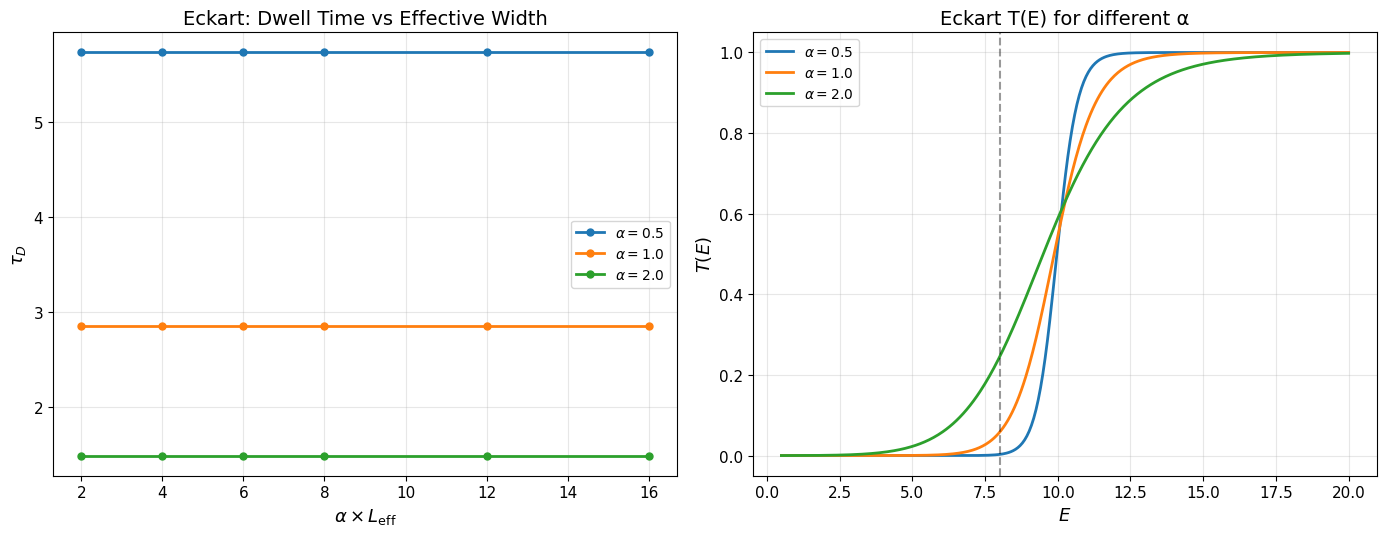

In [8]:
alpha_values = [0.5, 1.0, 2.0]
k0_hartman = 4.0
E_h = 0.5 * k0_hartman**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

for alpha in alpha_values:
    V0_e = 10.0
    effective_widths = np.array([2.0, 4.0, 6.0, 8.0, 12.0, 16.0]) / alpha
    dwell_e = []
    for w_eff in effective_widths:
        p_e = SimParams(V0=V0_e, k0=k0_hartman, sigma=10.0, x0=-30.0, alpha=alpha,
                         N_x=4096, N_t=4000, save_every=200, dt=0.005,
                         barrier_a=-w_eff/2, barrier_b=w_eff/2)
        res_e = propagate(p_e, 'eckart')
        dwell_e.append(res_e.dwell_time)
    ax1.plot(effective_widths * alpha, dwell_e, 'o-', linewidth=2, markersize=5,
             label=f'$\\alpha={alpha}$')

ax1.set_xlabel(r'$\alpha \times L_{\mathrm{eff}}$')
ax1.set_ylabel(r'$\tau_D$')
ax1.set_title('Eckart: Dwell Time vs Effective Width')
ax1.legend()

E_range = np.linspace(0.5, 20, 500)
for alpha in alpha_values:
    T_range = eckart_analytical_T_simple(E_range, V0_e, alpha)
    ax2.plot(E_range, T_range, linewidth=2, label=f'$\\alpha={alpha}$')
ax2.axvline(E_h, color='k', linestyle='--', alpha=0.4)
ax2.set_xlabel('$E$')
ax2.set_ylabel('$T(E)$')
ax2.set_title('Eckart T(E) for different α')
ax2.legend()

plt.tight_layout()
plt.show()